# Fase 4 (parte A) — Modelos de Machine Learning clásico
**Proyecto:** FruitVision — Clasificación de Calidad de Frutas

---
Dos modelos clásicos sobre características HOG + histograma de color HSV (1860 dims):
**Random Forest** y **XGBoost**, con **GridSearchCV (k=5)** optimizando F1-macro,
comparados contra una **línea base** (clase mayoritaria).

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, joblib, time
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb
from src.config import QUALITY_CLASSES, MODELS_DIR, FIGURES_DIR, SEED
from src.data.preprocessing import load_manifest
from src.features.extract import build_feature_matrix

## 1. Cargar características (HOG + color, cacheadas)

In [2]:
Xtr, ytr = build_feature_matrix(load_manifest('train'), 'train')
Xva, yva = build_feature_matrix(load_manifest('val'),   'val')
Xte, yte = build_feature_matrix(load_manifest('test'),  'test')
print("train", Xtr.shape, "| val", Xva.shape, "| test", Xte.shape)
print("clases:", dict(enumerate(QUALITY_CLASSES)))

features[train]:   0%|          | 0/6570 [00:00<?, ?it/s]

features[val]:   0%|          | 0/1061 [00:00<?, ?it/s]

features[test]:   0%|          | 0/1082 [00:00<?, ?it/s]

train (6570, 1860) | val (1061, 1860) | test (1082, 1860)
clases: {0: 'Premium', 1: 'Estándar', 2: 'Descarte'}


## 2. Línea base

In [3]:
dummy = DummyClassifier(strategy='most_frequent').fit(Xtr, ytr)
base_acc = accuracy_score(yte, dummy.predict(Xte)); base_f1 = f1_score(yte, dummy.predict(Xte), average='macro')
print(f"Baseline -> accuracy={base_acc:.3f} | f1_macro={base_f1:.3f}")

Baseline -> accuracy=0.347 | f1_macro=0.172


## 3. Random Forest + GridSearchCV

In [4]:
rf_grid = {'n_estimators':[200,400], 'max_depth':[None,20], 'min_samples_split':[2,5]}
t=time.time()
rf = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=1),
                  rf_grid, cv=5, scoring='f1_macro', n_jobs=-1).fit(Xtr, ytr)
print(f"[{time.time()-t:.0f}s]", rf.best_params_)
print(f"F1-macro CV={rf.best_score_:.3f} | val={f1_score(yva, rf.predict(Xva), average='macro'):.3f}")

[439s] {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 400}
F1-macro CV=0.765 | val=0.876


## 4. XGBoost + GridSearchCV

In [5]:
xgb_grid = {'learning_rate':[0.1,0.3], 'max_depth':[4,6], 'n_estimators':[200,400]}
t=time.time()
xg = GridSearchCV(xgb.XGBClassifier(tree_method='hist', random_state=SEED, n_jobs=1, eval_metric='mlogloss'),
                  xgb_grid, cv=5, scoring='f1_macro', n_jobs=-1).fit(Xtr, ytr)
print(f"[{time.time()-t:.0f}s]", xg.best_params_)
print(f"F1-macro CV={xg.best_score_:.3f} | val={f1_score(yva, xg.predict(Xva), average='macro'):.3f}")

/home/juan-pablo/anaconda3/envs/fruit-quality/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[2250s] {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400}
F1-macro CV=0.820 | val=0.938


## 5. Evaluación en test

In [6]:
def evaluate(model, name):
    pred = model.predict(Xte); acc = accuracy_score(yte, pred); f1 = f1_score(yte, pred, average='macro')
    print(f"=== {name} === accuracy={acc:.3f} | f1_macro={f1:.3f}")
    print(classification_report(yte, pred, target_names=QUALITY_CLASSES, digits=3))
    return acc, f1, pred
rf_acc, rf_f1, rf_pred = evaluate(rf, "Random Forest")
xg_acc, xg_f1, xg_pred = evaluate(xg, "XGBoost")

=== Random Forest === accuracy=0.891 | f1_macro=0.892
              precision    recall  f1-score   support

     Premium      0.947     0.840     0.891       363
    Estándar      0.929     0.881     0.904       344
    Descarte      0.820     0.949     0.880       375

    accuracy                          0.891      1082
   macro avg      0.899     0.890     0.892      1082
weighted avg      0.898     0.891     0.891      1082

=== XGBoost === accuracy=0.942 | f1_macro=0.942
              precision    recall  f1-score   support

     Premium      0.965     0.909     0.936       363
    Estándar      0.967     0.951     0.959       344
    Descarte      0.900     0.965     0.932       375

    accuracy                          0.942      1082
   macro avg      0.944     0.942     0.942      1082
weighted avg      0.943     0.942     0.942      1082



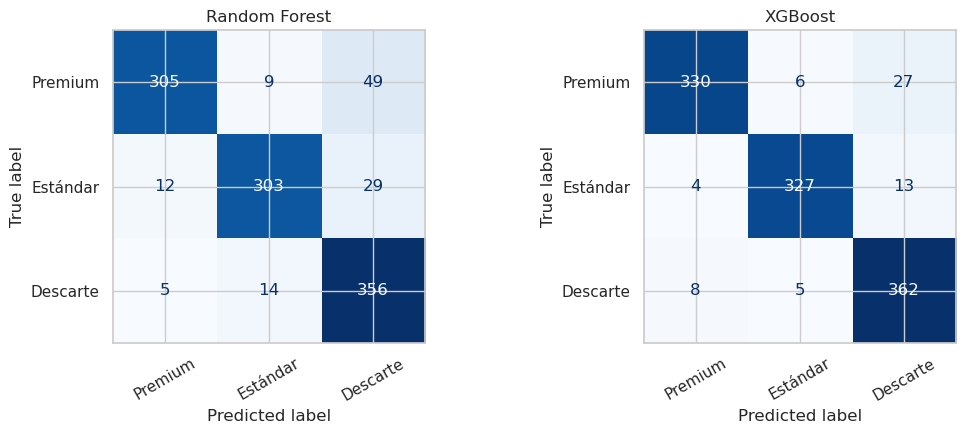

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a,(pred,name) in zip(ax, [(rf_pred,"Random Forest"),(xg_pred,"XGBoost")]):
    ConfusionMatrixDisplay(confusion_matrix(yte, pred), display_labels=QUALITY_CLASSES).plot(ax=a, cmap='Blues', colorbar=False)
    a.set_title(name); a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "fase4_ml_confusion.pdf", bbox_inches="tight"); plt.show()

## 6. Importancia por familia de características (RF)

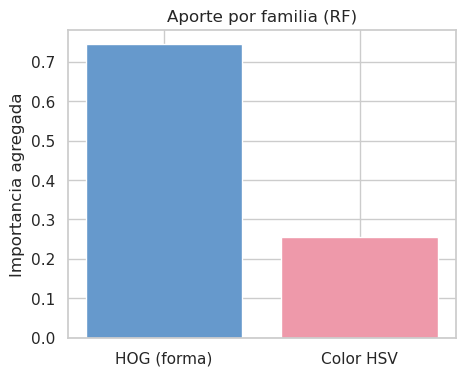

HOG=0.74 | Color=0.26


In [8]:
imp = rf.best_estimator_.feature_importances_; n_hog = 1764
plt.figure(figsize=(5,4))
plt.bar(['HOG (forma)','Color HSV'], [imp[:n_hog].sum(), imp[n_hog:].sum()], color=['#69c','#e9a'])
plt.ylabel('Importancia agregada'); plt.title('Aporte por familia (RF)')
plt.savefig(FIGURES_DIR / "fase4_ml_importancia.pdf", bbox_inches="tight"); plt.show()
print(f"HOG={imp[:n_hog].sum():.2f} | Color={imp[n_hog:].sum():.2f}")

## 7. Comparativa y guardado

In [9]:
results = pd.DataFrame({'modelo':['Baseline','Random Forest','XGBoost'],
    'accuracy':[base_acc, rf_acc, xg_acc], 'f1_macro':[base_f1, rf_f1, xg_f1]}).set_index('modelo')
print(results.round(3))
best = max([('random_forest', rf.best_estimator_, rf_f1), ('xgboost', xg.best_estimator_, xg_f1)], key=lambda t:t[2])
joblib.dump(best[1], MODELS_DIR / "best_quality_ml.pkl")
joblib.dump(rf.best_estimator_, MODELS_DIR / "random_forest.pkl")
joblib.dump(xg.best_estimator_, MODELS_DIR / "xgboost.pkl")
print(f"Mejor ML: {best[0]} -> best_quality_ml.pkl")

               accuracy  f1_macro
modelo                           
Baseline          0.347     0.172
Random Forest     0.891     0.892
XGBoost           0.942     0.942


Mejor ML: xgboost -> best_quality_ml.pkl


➡️ **Siguiente:** Fase 4 (parte B) — CNN (`cnn.ipynb`).